In [1]:
import requests
import pandas as pd

LAT, LON = 31.23, 121.47
TZ = "Asia/Shanghai"


def load_annual_extreme_days(start_year=2015, end_year=2025):
    """Annual sultry (>30°C) and hot (>35°C) days"""
    records = []

    for year in range(start_year, end_year + 1):
        url = (
            "https://archive-api.open-meteo.com/v1/archive"
            f"?latitude={LAT}&longitude={LON}"
            f"&start_date={year}-01-01&end_date={year}-12-31"
            "&daily=temperature_2m_max"
            f"&timezone={TZ}"
        )
        data = requests.get(url).json()
        df = pd.DataFrame(data["daily"])

        tmax = df["temperature_2m_max"]
        records.append({
            "Year": year,
            "Sultry_days": (tmax > 30).sum(),
            "Hot_days": (tmax > 35).sum()
        })

    return pd.DataFrame(records)

def load_hourly_warm_season(year):
    url = (
        "https://archive-api.open-meteo.com/v1/archive"
        f"?latitude={LAT}&longitude={LON}"
        f"&start_date={year}-05-01&end_date={year}-09-30"
        "&hourly=temperature_2m"
        f"&timezone={TZ}"
    )
    data = requests.get(url).json()
    df = pd.DataFrame(data["hourly"])

    df["time"] = pd.to_datetime(df["time"])
    df["month"] = df["time"].dt.month
    df["md"] = df["time"].dt.strftime("%m-%d")

    return df[["time", "month", "md", "temperature_2m"]]

d:\anaconda\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.3) or chardet (7.4.3)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


In [2]:
annual_df = load_annual_extreme_days()
df_2015 = load_hourly_warm_season(2015)
df_2025 = load_hourly_warm_season(2025)

In [3]:
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
import numpy as np
from matplotlib.patches import Patch
import os

# ===============================
# Global journal‑style settings
# ===============================
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.linewidth': 2,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.major.width': 2.0,
    'ytick.major.width': 2.0,
    'xtick.minor.visible': False,
    'ytick.minor.visible': False,
    'lines.solid_capstyle': 'round',
})

# ===============================
# Color manager
# ===============================
def hex_to_rgba(hex_color, alpha=1.0):
    hex_color = hex_color.lstrip('#')
    r, g, b = [int(hex_color[i:i+2], 16) / 255 for i in (0, 2, 4)]
    return (r, g, b, alpha)

COLORS = {
    'hot':       hex_to_rgba('#DA4048', 0.4),   # hot days (>35°C)
    'sultry':    hex_to_rgba('#BFD8EC', 1),   # sultry days (30–35°C)
    'year_2015': hex_to_rgba('#BFD8EC', 1),
    'year_2025': hex_to_rgba('#DA4048', 0.4),
}

def plot_group_figure(annual_df, df15, df25):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # =========================
    # Left panel (a): Stacked bars
    # =========================
    ax_left = axes[0]
    ax_left.bar(
        annual_df["Year"],
        annual_df["Hot_days"],
        color=COLORS['hot'],
        edgecolor='#DA4048',
        label="Hot days (>35°C)"
    )
    ax_left.bar(
        annual_df["Year"],
        annual_df["Sultry_days"] - annual_df["Hot_days"],
        bottom=annual_df["Hot_days"],
        color=COLORS['sultry'],
        edgecolor='#2171ae',
        label="Sultry days (30–35°C)"
    )

    ax_left.set_ylim(0, 150)
    ax_left.set_yticks(range(0, 151, 50))
    ax_left.set_xlabel("Year")
    ax_left.set_ylabel("Number of temperature extreme days")
    ax_left.legend(frameon=False)

    years = sorted(annual_df["Year"].unique())
    ax_left.set_xticks(years)
    ax_left.set_xticklabels(years, rotation=0)

    # Subplot label (a)
    ax_left.text(
        -0.09, 1, 'a',
        transform=ax_left.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='left'
    )

    # =========================
    # Right panel (b): Monthly boxplots (May–Sep)
    # =========================
    ax_right = axes[1]
    months = list(range(5, 10))
    month_labels = ["May", "Jun.", "Jul.", "Aug.", "Sep."]

    box_data = []
    positions = []
    stats_results = []

    pos = 1.0
    gap = 1.3
    offset = 0.35

    for m in months:
        d15 = df15[df15["md"].str.startswith(f"{m:02d}-")]["temperature_2m"].dropna()
        d25 = df25[df25["md"].str.startswith(f"{m:02d}-")]["temperature_2m"].dropna()

        box_data.extend([d15, d25])
        positions.extend([pos, pos + offset])

        if len(d15) > 0 and len(d25) > 0:
            _, p = mannwhitneyu(d15, d25, alternative="two-sided")
        else:
            p = np.nan

        stats_results.append((pos, pos + offset, d15, d25, p))
        pos += gap

    bp = ax_right.boxplot(
        box_data,
        positions=positions,
        widths=0.28,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="black", linewidth=1.8),
        boxprops=dict(linewidth=1.2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2)
    )

    for i, box in enumerate(bp["boxes"]):
        box.set_facecolor(COLORS['year_2015'] if i % 2 == 0 else COLORS['year_2025'])

    month_centers = [1.0 + i * gap + offset / 2 for i in range(len(months))]
    ax_right.set_xticks(month_centers)
    ax_right.set_xticklabels(month_labels)
    ax_right.set_ylabel("Hourly air temperature (°C)")

    ax_right.set_ylim(5, 45)
    ax_right.set_yticks(np.arange(5, 46, 10))

    for (x1, x2, d15, d25, p) in stats_results:
        if np.isnan(p):
            continue
        if p < 0.001:
            sig = "***"
        elif p < 0.01:
            sig = "**"
        elif p < 0.05:
            sig = "*"
        else:
            sig = "ns"

        y = max(d15.max(), d25.max()) + 0.6
        ax_right.plot(
            [x1, x1, x2, x2],
            [y - 0.2, y, y, y - 0.2],
            lw=1.2,
            color="black"
        )
        ax_right.text(
            (x1 + x2) / 2,
            y + 0.1,
            sig,
            ha="center",
            va="bottom"
        )

    legend_handles = [
        Patch(facecolor=COLORS['year_2015'], edgecolor="black", label="2015"),
        Patch(facecolor=COLORS['year_2025'], edgecolor="black", label="2025")
    ]
    ax_right.legend(handles=legend_handles, frameon=False, loc="upper left")

    # Subplot label (b)
    ax_right.text(
        -0.09, 1, 'b',
        transform=ax_right.transAxes,
        fontsize=16,
        fontweight='bold',
        va='top',
        ha='left'
    )


    # =========================
    # Save figure
    # =========================
    output_dir = r"SI_Figures"
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, "FigS3.tiff")
    plt.tight_layout()
    plt.savefig(output_path, format="tiff", dpi=600, bbox_inches="tight")
    plt.show()

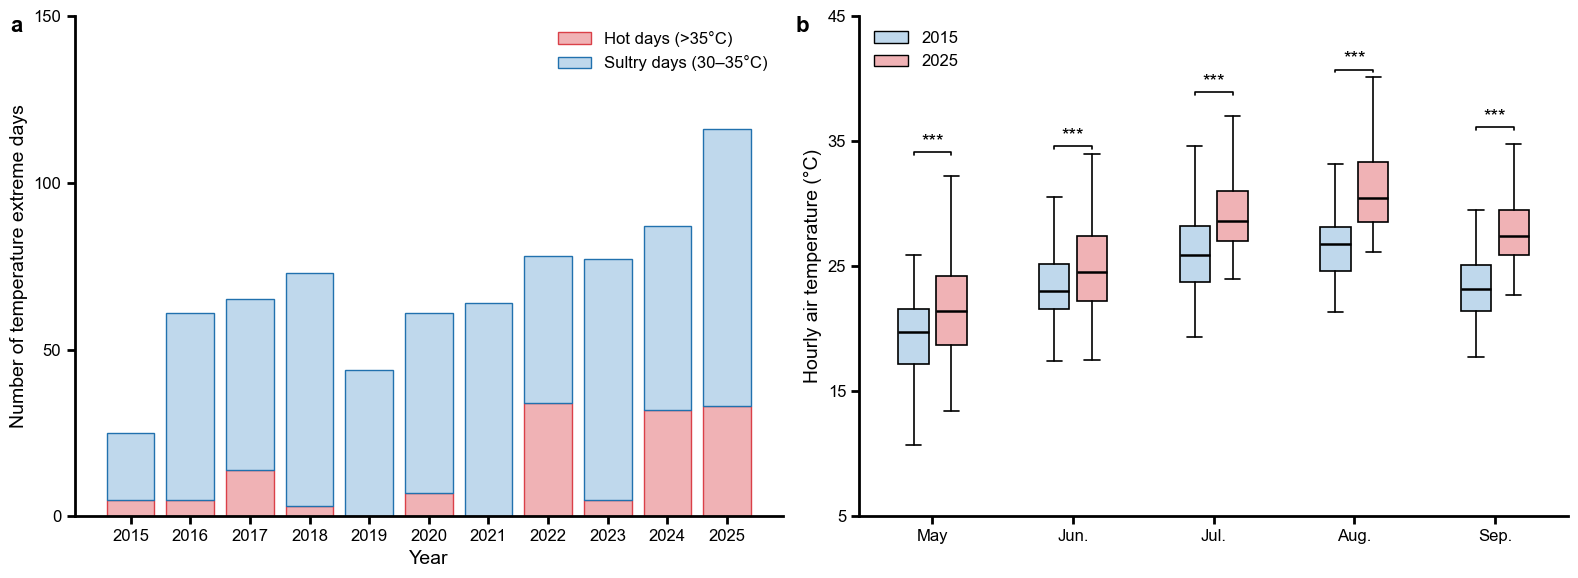

In [4]:
plot_group_figure(annual_df, df_2015, df_2025)